In [1]:
%load_ext autoreload
%autoreload 2

# import packages
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime as dt
from glob import glob
from tqdm import tqdm

# import partial packages
from sklearn.cluster import KMeans, OPTICS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, ParameterGrid

from hdbscan import HDBSCAN
from hdbscan.validity import validity_index


directory = '/scratch/6256481/'

# import sys
# sys.path.insert(0, directory + f'python/py_code/')





# Goal
- Kmeans
- DBSCAN
- HBBSCAN
- OPTICS

# Open and transform data

In [2]:
f = directory + 'results/single_smoothed/global_50_02_smoothed.nc'
ds = xr.open_dataset(f)


In [3]:
df = ds.to_dataframe().reset_index()

In [4]:
slopeCols    = ['slope_out_normalized', 'slope_right_normalized', 'slope_left_normalized', 'slope_inn_normalized']
slopeSCols   = ['slope_out_normalized_smooth', 'slope_right_normalized_smooth', 'slope_left_normalized_smooth', 'slope_inn_normalized_smooth']
slopeSTCols = ['slope_out_normalized_smoothSTD', 'slope_right_normalized_smoothSTD', 'slope_left_normalized_smoothSTD', 'slope_inn_normalized_smoothSTD']

In [5]:
def scale(df, scaleCols):
    dfCluster = df[scaleCols].copy()
    dfCluster = dfCluster.dropna()
    X = dfCluster[scaleCols]
    # === Standardize features ===
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled
dfCluster = df[['file', 'combined_reach_id', 'bendID'] +slopeCols + slopeSCols + slopeSTCols].copy().dropna()
X_scaledO   = scale(dfCluster, slopeCols)
X_scaledS   = scale(dfCluster, slopeSCols)
X_scaledST  = scale(dfCluster, slopeSCols + slopeSTCols)
X_scaledSO  = scale(dfCluster, slopeCols + slopeSCols)
X_scaledSOT = scale(dfCluster, slopeCols + slopeSCols + slopeSTCols)

### OLD

In [84]:
dsSubset = ds[[
    'combined_reach_id', 'reach_id', 'file', 'bendLen', 'up_reach_id', 
    'networkGraph', 'networkGroup', 'river_name',
    'dn_connected_reach', 'rch_id_dn', 'rch_id_dn_orig', 'rch_id_up', 'rch_id_up_orig',
    'combined_reach_up', 'combined_reach_dn',
    'river_segment', 'river_segment_order',
    'ER_inn', 'ER_out', 'slope_inn', 'slope_out',
    'ER_left', 'ER_right', 'slope_left', 'slope_right',
    'apex', 'catchment_position', 'bendWidths', 'bendMaxWidths',
    'cp_height', 'cm_height','bendDistOut','max_dist_out','bendHeight',
    'sin', 'ang', 'conFactor', 'catchment_position', 'combined_reach_len'
    ]]
df = dsSubset.to_dataframe().reset_index()

df['ER_max_inout']    = df[['ER_inn', 'ER_out']].max(axis = 1)
df['slope_max_inout'] = df[['slope_inn', 'slope_out']].max(axis = 1)


df['slope_diff_bendSide']     = df['slope_inn']     - df['slope_out']
df['slope_diff_bendSide_abs'] = abs(df['slope_inn'] - df['slope_out'])
df['slope_diff_side']         = df['slope_left']    - df['slope_right']


df['ER_diff_bendSide']     = df['ER_inn']     - df['ER_out']
df['ER_diff_bendSide_abs'] = abs(df['ER_inn'] - df['ER_out'])
df['ER_diff_side']         = df['ER_left']    - df['ER_right']

df['nonDimAmp'] = df['apex'] / df['bendMaxWidths']

df['catch_height'] = df['bendHeight'] * df['catchment_position']

df['slope_max'] = (df['cm_height'] - df['cp_height']) / (df['bendMaxWidths']*0.5)
df['slope_out_normalized'] = df['slope_out']   / df['slope_max']
df['slope_inn_normalized'] = df['slope_inn']   / df['slope_max']
df['slope_left_normalized'] = df['slope_left']  / df['slope_max']
df['slope_right_normalized'] = df['slope_right'] / df['slope_max']


df['bend_catch_pos'] = df['bendDistOut'] / df['max_dist_out']

df['glob_reach_id'] = df.groupby(['file', 'combined_reach_id']).ngroup()
dfG = df.groupby(['glob_reach_id'], as_index = False)[['file', 'combined_reach_id', 'combined_reach_len', 'sin']].first()


In [4]:
# Define which columns to apply which aggregations
first_columns = ['file', 'combined_reach_id']
# agg_columns = ['ER_left'    , 'ER_right'  , 'ER_out'   , 'ER_inn', 
            #    'slope_right', 'slope_left', 'slope_out', 'slope_inn']
agg_columns = ['slope_right_normalized', 'slope_left_normalized', 'slope_out_normalized', 'slope_inn_normalized']

# Build aggregation dictionary
agg_dict = {col: 'first' for col in first_columns}
agg_dict.update({col: ['mean', 'std', 'min', 'max', 'median'] for col in agg_columns})

# Apply groupby and aggregations
grouped = df.groupby("glob_reach_id", as_index = False).agg(agg_dict)

# Optional: flatten multi-level column names
grouped.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in grouped.columns]
grouped = grouped.reset_index()
grouped = grouped.rename(columns = {'glob_reach_id_':'glob_reach_id'})

df  =df.merge(grouped, how = 'left', on = 'glob_reach_id')

In [ ]:
clusterAllColumns  = [col for col in df.columns if 'normalized' in col]
clusterBendColumns = ['slope_out_normalized', 'slope_inn_normalized']
clusterAggColumns  = [col for col in df.columns if 'normalized_' in col]

df[['glob_reach_id'] + clusterAllColumns]
df[['glob_reach_id'] + clusterAllColumns]

,glob_reach_id,slope_out_normalized,slope_inn_normalized,slope_left_normalized,slope_right_normalized,slope_right_normalized_mean,slope_right_normalized_std,slope_right_normalized_min,slope_right_normalized_max,slope_right_normalized_median,...,slope_out_normalized_mean,slope_out_normalized_std,slope_out_normalized_min,slope_out_normalized_max,slope_out_normalized_median,slope_inn_normalized_mean,slope_inn_normalized_std,slope_inn_normalized_min,slope_inn_normalized_max,slope_inn_normalized_median
0,12584,0.295685,0.101925,0.295685,0.101925,0.265644,0.186060,0.054776,0.819673,0.209918,...,0.409147,0.262681,0.060787,1.000000,0.331490,0.265644,0.186060,0.054776,0.819673,0.209918
1,12584,0.060787,0.209918,0.060787,0.209918,0.265644,0.186060,0.054776,0.819673,0.209918,...,0.409147,0.262681,0.060787,1.000000,0.331490,0.265644,0.186060,0.054776,0.819673,0.209918
2,12584,0.265816,0.819673,0.265816,0.819673,0.265644,0.186060,0.054776,0.819673,0.209918,...,0.409147,0.262681,0.060787,1.000000,0.331490,0.265644,0.186060,0.054776,0.819673,0.209918
3,12584,1.000000,0.087275,1.000000,0.087275,0.265644,0.186060,0.054776,0.819673,0.209918,...,0.409147,0.262681,0.060787,1.000000,0.331490,0.265644,0.186060,0.054776,0.819673,0.209918
4,12584,0.139857,0.675535,0.139857,0.675535,0.265644,0.186060,0.054776,0.819673,0.209918,...,0.409147,0.262681,0.060787,1.000000,0.331490,0.265644,0.186060,0.054776,0.819673,0.209918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1492202,85366,-0.000602,0.001271,-0.000602,0.001271,0.003083,0.003780,-0.004633,0.010066,0.002628,...,0.003233,0.005803,-0.009158,0.017670,0.002546,0.003083,0.003780,-0.004633,0.010066,0.002628
1492203,85366,0.005794,0.005410,0.005794,0.005410,0.003083,0.003780,-0.004633,0.010066,0.002628,...,0.003233,0.005803,-0.009158,0.017670,0.002546,0.003083,0.003780,-0.004633,0.010066,0.002628
1492204,85367,0.009559,0.000603,0.009559,0.000603,0.000603,NaN,0.000603,0.000603,0.000603,...,0.009559,NaN,0.009559,0.009559,0.009559,0.000603,NaN,0.000603,0.000603,0.000603
1492205,85374,0.001764,0.000336,0.001764,0.000336,0.001285,0.001342,0.000336,0.002234,0.001285,...,0.016577,0.020948,0.001764,0.031389,0.016577,0.001285,0.001342,0.000336,0.002234,0.001285


# Kmeans clustering

In [ ]:
def kmeans_elbow(X, k):
    # === Elbow Method to determine optimal k ===
    inertia = []
    k_range = range(1, k)

    for k in tqdm(k_range):
        kmeans = KMeans(n_clusters=k,
                        init='k-means++',
                        random_state=42,
                        max_iter=300)
        kmeans.fit(X)

        inertia.append(kmeans.inertia_)  # Sum of squared distances to closest cluster center
        
    return k_range, inertia




## Elbow Curve

In [22]:
krO,  inertiaO   = kmeans_elbow(X_scaledO , 15)
krS,  inertiaS   = kmeans_elbow(X_scaledS , 15)
krST, inertiaST  = kmeans_elbow(X_scaledST, 15)
krSO, inertiaSO  = kmeans_elbow(X_scaledSO, 15)
krSOT, inertiaSOT = kmeans_elbow(X_scaledSOT, 15)

100%|██████████| 14/14 [00:25<00:00,  1.83s/it]


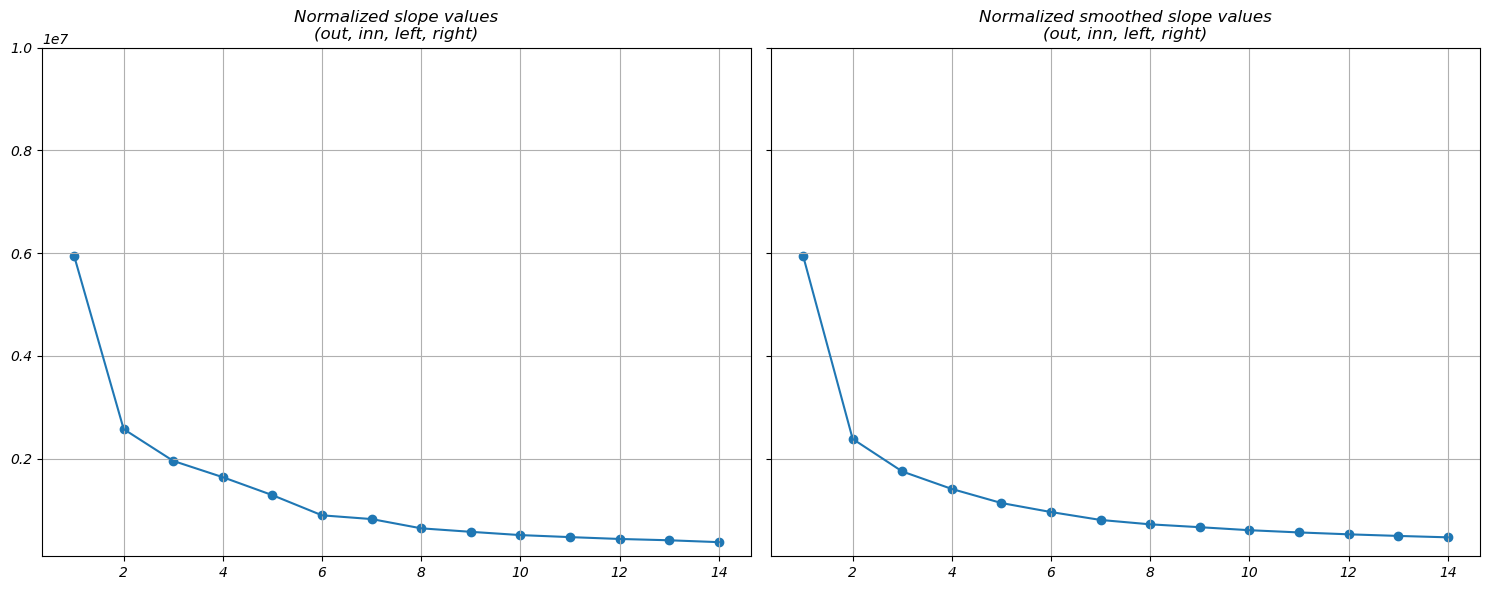

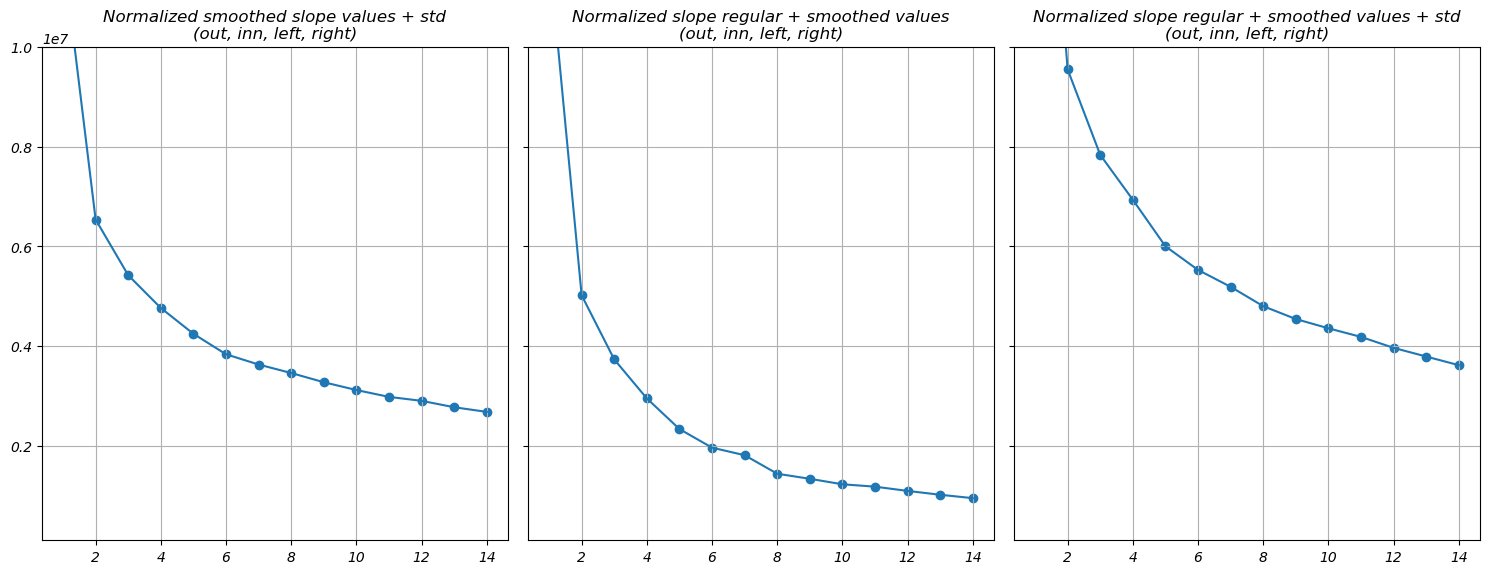

In [24]:
f, ax = plt.subplots(ncols = 2, figsize = [15,6], sharey=True)
ax[0].scatter(krO, inertiaO)
ax[0].plot(krO, inertiaO)
ax[0].grid()
ax[0].set_title('Normalized slope values\n(out, inn, left, right)')

ax[1].scatter(krS, inertiaS)
ax[1].plot(krS, inertiaS)
ax[1].grid()
ax[1].set_title('Normalized smoothed slope values\n(out, inn, left, right)')
plt.ylim([1e5,1e7])
plt.tight_layout()
plt.show()
f, ax = plt.subplots(ncols = 3, figsize = [15,6], sharey=True)
ax[0].scatter(krST, inertiaST)
ax[0].plot(krST, inertiaST)
ax[0].grid()
ax[0].set_title('Normalized smoothed slope values + std\n(out, inn, left, right)')

ax[1].scatter(krSO, inertiaSO)
ax[1].plot(krSO, inertiaSO)
ax[1].grid()
ax[1].set_title('Normalized slope regular + smoothed values\n(out, inn, left, right)')

ax[2].scatter(krSOT, inertiaSOT)
ax[2].plot(krSOT, inertiaSOT)
ax[2].grid()
ax[2].set_title('Normalized slope regular + smoothed values + std\n(out, inn, left, right)')

plt.ylim([1e5,1e7])
plt.tight_layout()
plt.show()

## Silhouette score
Apply on smaller number of centroids since it is computationally expensive

In [13]:
def resampleSilhouette(algo, X, sampleSize, printScore = False, random_state = 42):

    labels = algo.fit_predict(X)
    X_sample, y_sample = resample(X, labels, n_samples=sampleSize, random_state=random_state)
    score = silhouette_score(X_sample, y_sample)
    if printScore == True:
        print("Silhouette Score (sampled):", score)
    return score


In [ ]:
O, S, ST, SO, SOT = [],[],[],[],[]
sample = 10000
printB = True
for i in range(1):
    randomState = 42+i
    for c in [3]:
        kmeans = KMeans(n_clusters=c,init='k-means++',random_state=42)
        print(i, c)
        O.append(resampleSilhouette(kmeans, X_scaledO  , sample, printB, randomState))
        S.append(resampleSilhouette(kmeans, X_scaledS  , sample, printB, randomState))
        ST.append(resampleSilhouette(kmeans, X_scaledST , sample, printB, randomState))
        SO.append(resampleSilhouette(kmeans, X_scaledSO , sample, printB, randomState))
        SOT.append(resampleSilhouette(kmeans, X_scaledSOT, sample, printB, randomState))
        

0 3
Silhouette Score (sampled): 0.602242917941741
Silhouette Score (sampled): 0.5400998587558985
Silhouette Score (sampled): 0.46882173850713005
Silhouette Score (sampled): 0.5587267677719708
Silhouette Score (sampled): 0.4598598321858109


In [19]:
print(np.mean(O[0::6]), np.std(O[0::6]))
print(np.mean(O[1::6]), np.std(O[1::6]))
print(np.mean(O[2::6]), np.std(O[2::6]))
print(np.mean(O[3::6]), np.std(O[3::6]))
print(np.mean(O[4::6]), np.std(O[4::6]))
print(np.mean(O[5::6]), np.std(O[5::6]))
print()
print(np.mean(S[0::6]), np.std(S[0::6]))
print(np.mean(S[1::6]), np.std(S[1::6]))
print(np.mean(S[2::6]), np.std(S[2::6]))
print(np.mean(S[3::6]), np.std(S[3::6]))
print(np.mean(S[4::6]), np.std(S[4::6]))
print(np.mean(S[5::6]), np.std(S[5::6]))
print()
print(np.mean(ST[0::6]), np.std(ST[0::6]))
print(np.mean(ST[1::6]), np.std(ST[1::6]))
print(np.mean(ST[2::6]), np.std(ST[2::6]))
print(np.mean(ST[3::6]), np.std(ST[3::6]))
print(np.mean(ST[4::6]), np.std(ST[4::6]))
print(np.mean(ST[5::6]), np.std(ST[5::6]))
print()
print(np.mean(SO[0::6]), np.std(SO[0::6]))
print(np.mean(SO[1::6]), np.std(SO[1::6]))
print(np.mean(SO[2::6]), np.std(SO[2::6]))
print(np.mean(SO[3::6]), np.std(SO[3::6]))
print(np.mean(SO[4::6]), np.std(SO[4::6]))
print(np.mean(SO[5::6]), np.std(SO[5::6]))
print()
print(np.mean(SOT[0::6]), np.std(SOT[0::6]))
print(np.mean(SOT[1::6]), np.std(SOT[1::6]))
print(np.mean(SOT[2::6]), np.std(SOT[2::6]))
print(np.mean(SOT[3::6]), np.std(SOT[3::6]))
print(np.mean(SOT[4::6]), np.std(SOT[4::6]))
print(np.mean(SOT[5::6]), np.std(SOT[5::6]))

0.5040901102728882 0.001897751972385832
0.528247241162269 0.0016554469477185225
0.5559425300649937 0.0019626238521821744
0.5616721080959792 0.0021998089895500666
0.5720807275183568 0.0021385793132839056
0.5764846754595727 0.002267193728979899

0.5589295450254596 0.002813764900257717
0.5041781914987088 0.0028577946452896406
0.49601560456117566 0.003379258982062198
0.5116905236503453 0.003511801723329115
0.478289426212496 0.0029388987623739297
0.45775091042670785 0.0036448588286698276

0.4780764211621678 0.0025205201969903854
0.46680717934828786 0.0019800835224326415
0.39528166247558744 0.0035495115647075225
0.3875577211428834 0.003651044234008513
0.3853168035193026 0.003564848576340006
0.3838715707827997 0.003747969339189491

0.580573786036351 0.0027503553801378248
0.5156143519930463 0.0031996703809515675
0.5036550254068292 0.0033345947619256573
0.4694158396479534 0.0032810922764277303
0.48865654477741344 0.003467246264154759
0.4795954132595058 0.003283572098010312

0.4575263744770046 0

## Cluster distribution

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# labels is a 1D array or list of cluster assignments
# Example: labels = model.fit_predict(X)

def plot_cluster_histogram(labels, title="Cluster Distribution"):
    labels = np.array(labels)
    unique_labels, counts = np.unique(labels, return_counts=True)

    # Optional: sort clusters by label
    sorted_indices = np.argsort(unique_labels)
    unique_labels = unique_labels[sorted_indices]
    counts = counts[sorted_indices]

    plt.figure(figsize=(8, 5))
    plt.bar([str(lbl) for lbl in unique_labels], counts, color='skyblue', edgecolor='black')
    plt.xlabel("Cluster Label")
    plt.ylabel("Number of Samples")
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()



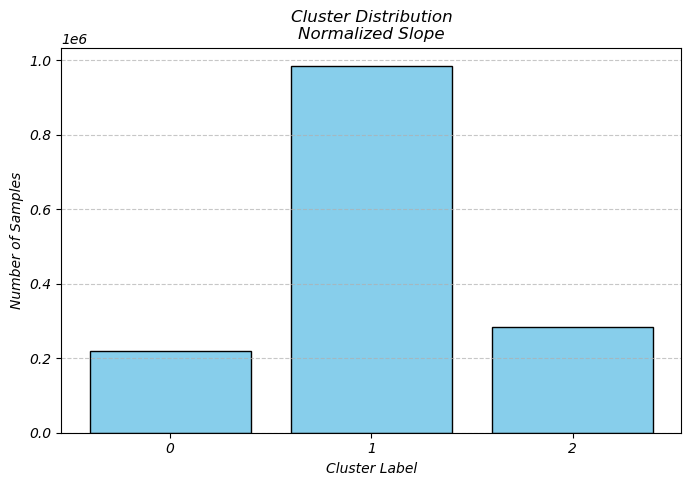

In [11]:
kmeans = KMeans(n_clusters=3,init='k-means++',random_state=42)
labelsO = kmeans.fit_predict(X_scaledO)
plot_cluster_histogram(labelsO, title = 'Cluster Distribution\nNormalized Slope')

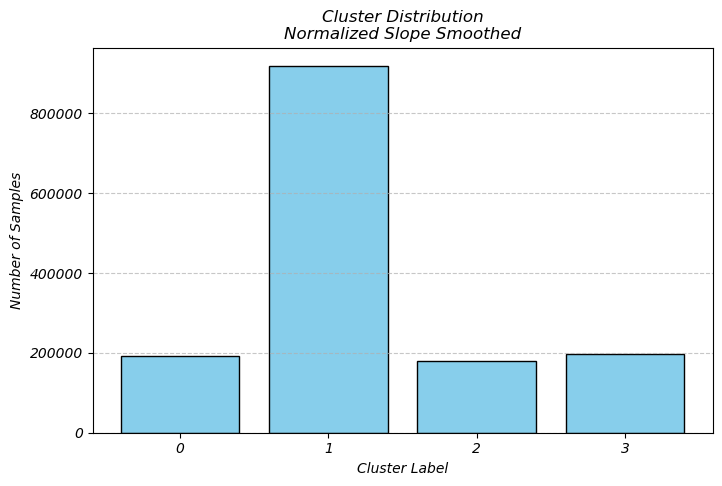

In [12]:
kmeans = KMeans(n_clusters=4,init='k-means++',random_state=42)
labelsS = kmeans.fit_predict(X_scaledS)
plot_cluster_histogram(labelsS, title = 'Cluster Distribution\nNormalized Slope Smoothed')

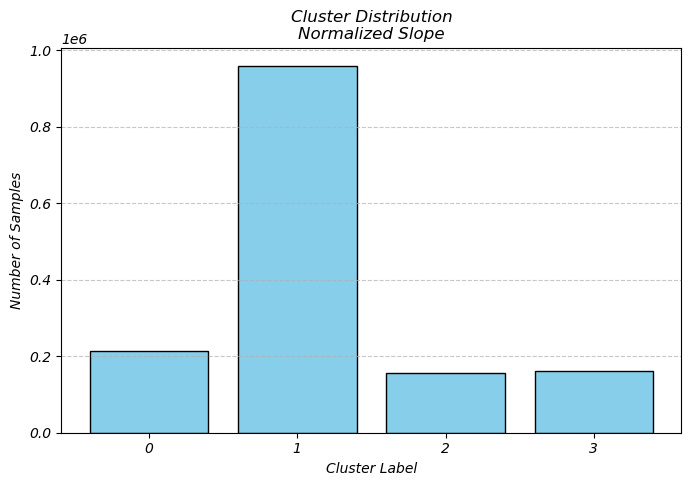

In [13]:
kmeans = KMeans(n_clusters=4,init='k-means++',random_state=42)
labelsSO = kmeans.fit_predict(X_scaledSO)
plot_cluster_histogram(labelsSO, title = 'Cluster Distribution\nNormalized Slope')

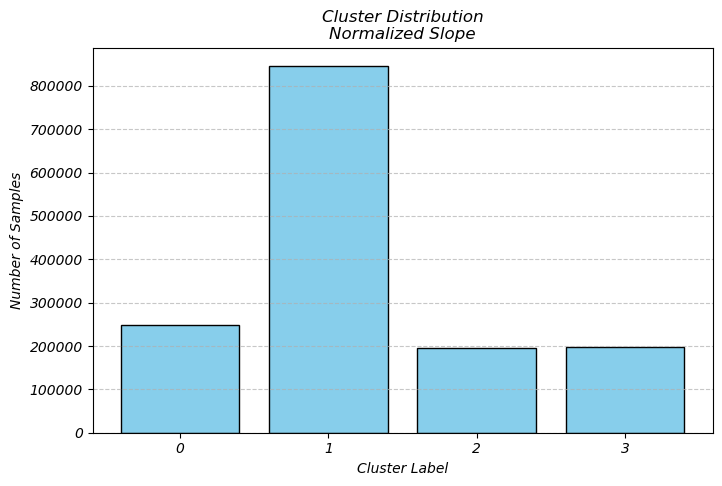

In [14]:
kmeans = KMeans(n_clusters=4,init='k-means++',random_state=42)
labelsST = kmeans.fit_predict(X_scaledST)
plot_cluster_histogram(labelsST, title = 'Cluster Distribution\nNormalized Slope')

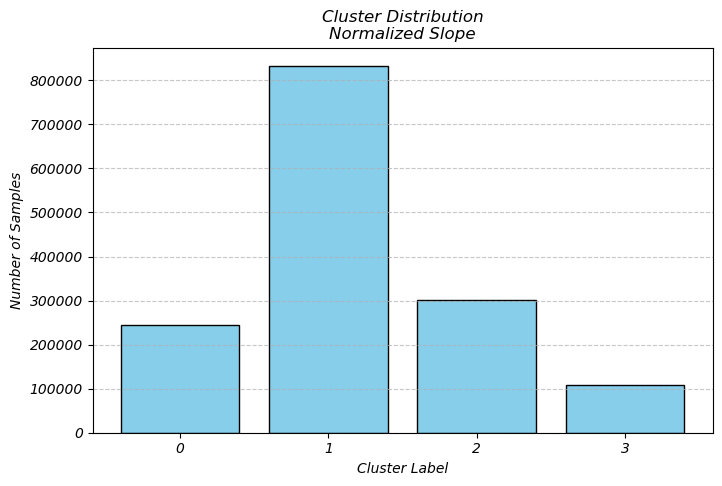

In [15]:
kmeans = KMeans(n_clusters=4,init='k-means++',random_state=42)
labelsSOT = kmeans.fit_predict(X_scaledSOT)
plot_cluster_histogram(labelsSOT, title = 'Cluster Distribution\nNormalized Slope')

### Match labels with dataset

In [16]:
dfCluster['Kmeans_O4']   = labelsO
dfCluster['Kmeans_S4']   = labelsS
dfCluster['Kmeans_ST4']  = labelsST
dfCluster['Kmeans_SO4']  = labelsSO
dfCluster['Kmeans_SOT4'] = labelsSOT

# Histogram with clusters

In [7]:
labelTextSize = 15

In [9]:
import seaborn as sns

In [19]:
dfCluster['slope_out_normalized_log'] = np.log10(df['slope_out_normalized'])

/home/6256481/.conda/envs/RivAlg10/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/6256481/.conda/envs/RivAlg10/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


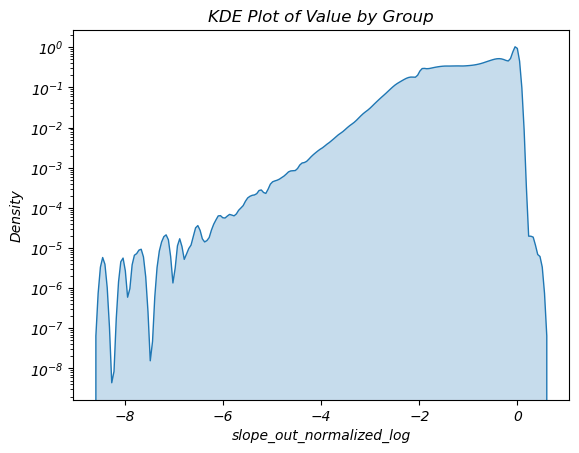

In [38]:
sns.kdeplot(data=dfCluster, x="slope_out_normalized_log", fill=True, common_norm=False)
plt.title("KDE Plot of Value by Group")
# plt.xscale('log')
plt.yscale('log')
plt.show()

In [41]:
A = gpd.read_file(glob(directory + 'results/new_segments/vector/*sa*01*')[0])

In [52]:
df.columns

Index(['level_0', 'index', 'combined_reach_id', 'reach_id', 'file', 'bendLen',
       'up_reach_id', 'networkGraph', 'networkGroup', 'river_name',
       'dn_connected_reach', 'rch_id_dn', 'rch_id_dn_orig', 'rch_id_up',
       'rch_id_up_orig', 'combined_reach_up', 'combined_reach_dn', 'ER_inn',
       'ER_out', 'slope_inn', 'slope_out', 'ER_left', 'ER_right', 'slope_left',
       'slope_right', 'apex', 'catchment_position', 'bendWidths',
       'bendMaxWidths', 'cp_height', 'cm_height', 'bendDistOut',
       'max_dist_out', 'bendHeight', 'bendSin', 'sin', 'ang', 'conFactor',
       'combined_reach_len', 'ER_max_inout', 'slope_max_inout',
       'slope_diff_bendSide', 'slope_diff_bendSide_abs', 'slope_diff_side',
       'ER_diff_bendSide', 'ER_diff_bendSide_abs', 'ER_diff_side', 'nonDimAmp',
       'catch_height', 'slope_max', 'slope_out_normalized',
       'slope_inn_normalized', 'slope_left_normalized',
       'slope_right_normalized', 'bend_catch_pos', 'glob_reach_id', 'bendRank',
 

In [57]:
297/2

148.5

In [ ]:
df = df.reset_index(drop=True)


Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       146930, 146931, 146932, 146933, 146934, 146935, 146936, 146937, 146938,
       146939],
      dtype='int64', length=146940)

In [46]:
A.loc[(A['combined_reach_id'].isin([14600, 13141, 14668, 13142, 14952, 14601])) & (~A['reach_id'].isin([62297800011,
62297700671,
62297600031,
62297600051,
62297600041])), 'reach_id'].values

array([62297100051, 62297100061, 62297100071, 62297100081, 62297100091,
       62297100101, 62297100111, 62297100121, 62297100131, 62297100141,
       62297100151, 62297300011, 62297300021, 62297300031, 62297300041,
       62297300051, 62297300061, 62297300071, 62297300081, 62297300091,
       62297300101, 62297300111, 62297300121, 62297300133, 62297300141,
       62297300151, 62297300163, 62297300171, 62297500011, 62297500021,
       62297500031, 62297500041, 62297500051, 62297500061, 62297500071,
       62297500081, 62297500091, 62297500101, 62297500111, 62297500121,
       62297500131, 62297500141, 62297500151, 62297500161, 62297500171,
       62297500181, 62297500191, 62297500201, 62297500211, 62297500221,
       62297500231, 62297500241, 62297500251, 62297500261, 62297500271,
       62297500281, 62297500291, 62297500301, 62297500311, 62297500321,
       62297500331, 62297600011, 62297600021, 62297700041, 62297700051,
       62297700061, 62297700071, 62297700081, 62297700091, 62297

In [2]:
from sklearn.model_selection import train_test_split, ParameterGrid


In [3]:
size =100
param_grid = {
    "min_cluster_size": [int(size * 0.0001), int(size * 0.001), int(size * 0.005), int(size * 0.01)],
    "min_samples":      [int(size * 0.00001), int(size * 0.0001), int(size * 0.001)]
}

grid = ParameterGrid(param_grid)

for params in grid:
    print(params)

{'min_cluster_size': 0, 'min_samples': 0}
{'min_cluster_size': 0, 'min_samples': 0}
{'min_cluster_size': 0, 'min_samples': 0}
{'min_cluster_size': 0, 'min_samples': 0}
{'min_cluster_size': 0, 'min_samples': 0}
{'min_cluster_size': 0, 'min_samples': 0}
{'min_cluster_size': 0, 'min_samples': 0}
{'min_cluster_size': 0, 'min_samples': 0}
{'min_cluster_size': 0, 'min_samples': 0}
{'min_cluster_size': 1, 'min_samples': 0}
{'min_cluster_size': 1, 'min_samples': 0}
{'min_cluster_size': 1, 'min_samples': 0}


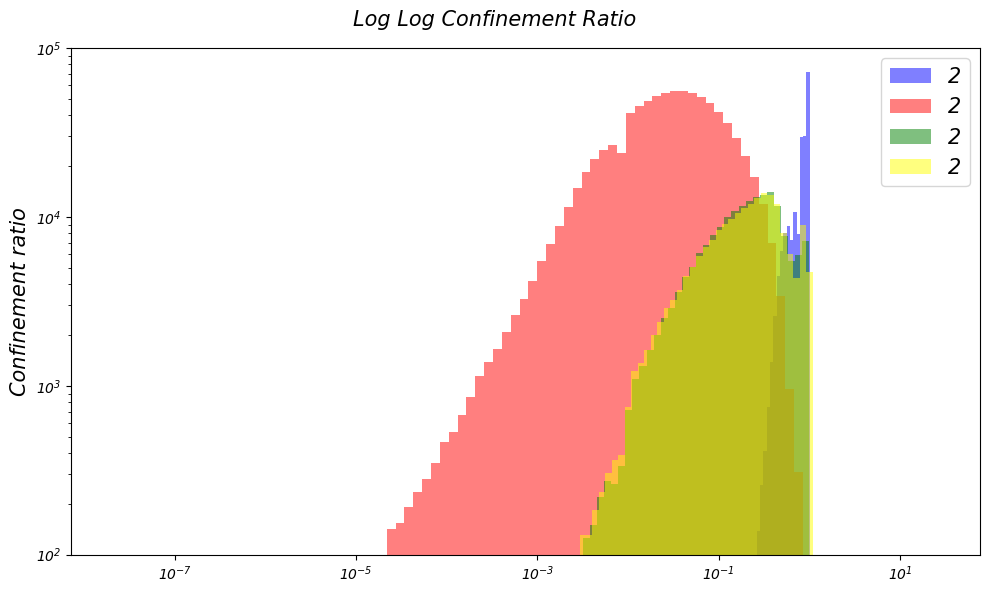

In [30]:
f, ax = plt.subplots(nrows = 1, ncols = 1, figsize  = [10,6], squeeze = False)
X = ['slope_inn_normalized']
Y = [0,1,2,3 ]
# X = ['ER_out_2', 'ER_out_4']
color = ['blue', 'red', 'green', 'yellow']
leg = ['2', '4', '8', '15']
c = r = 0
for j in range(len(Y)):
    for i in range(len(X)):
        x = dfCluster.loc[dfCluster['Kmeans_S4'] == j,(X[i])]
        if x.min() <= 0:
            x = x[x > 0]
        bin_edges = np.logspace(np.log10(x.min()), np.log10(x.max()), num=80)

        # Create histogram
        ax[r,c].hist(x, bins=bin_edges, alpha=0.5, color = color[j], label = leg[i])
ax[r,c].set_xscale('log')
ax[r,c].set_yscale('log')
ax[r,c].set_ylabel('Count'            , fontsize = labelTextSize)
ax[r,c].set_ylabel('Confinement ratio', fontsize = labelTextSize)

f.suptitle('Log Log Confinement Ratio', fontsize = labelTextSize)
plt.tight_layout()
plt.legend(fontsize = labelTextSize)
plt.ylim([10**2,10**5])
plt.show()

In [36]:
dfCluster.columns

Index(['file', 'combined_reach_id', 'bendID', 'slope_out_normalized',
       'slope_right_normalized', 'slope_left_normalized',
       'slope_inn_normalized', 'slope_out_normalized_smooth',
       'slope_right_normalized_smooth', 'slope_left_normalized_smooth',
       'slope_inn_normalized_smooth', 'slope_out_normalized_smoothSTD',
       'slope_right_normalized_smoothSTD', 'slope_left_normalized_smoothSTD',
       'slope_inn_normalized_smoothSTD', 'Kmeans_O4', 'Kmeans_S4',
       'Kmeans_ST4', 'Kmeans_SO4', 'Kmeans_SOT4', 'slope_out_normalized_log'],
      dtype='object')

KeyError: 'ER_out'

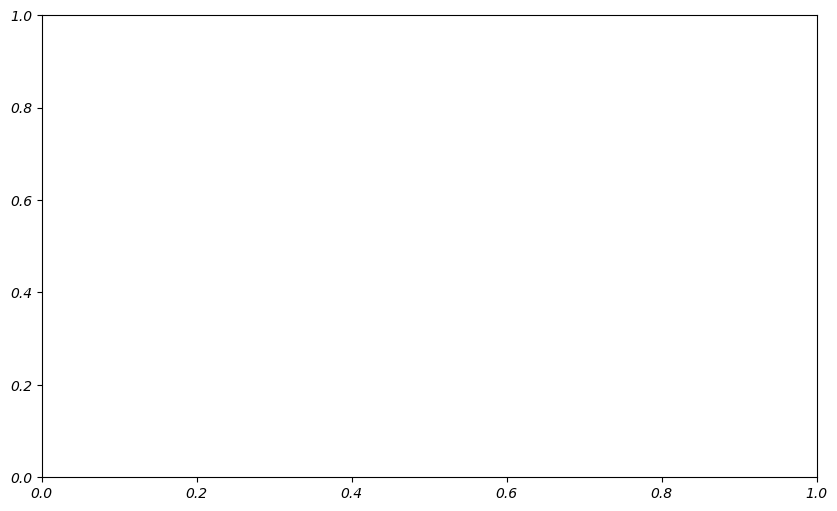

In [34]:
f, ax = plt.subplots(nrows = 1, ncols = 1, figsize  = [10,6], squeeze = False)
X = ['ER_out']
Y = [0,1,2,3 ]
# X = ['ER_out_2', 'ER_out_4']
color = ['blue', 'red', 'green', 'yellow']
leg = ['2', '4', '8', '15']
c = r = 0
for j in range(len(Y)):
    for i in range(len(X)):
        x = dfCluster.loc[dfCluster['Kmeans_SO4'] == j,(X[i])]
        if x.min() <= 0:
            x = x[x > 0]
        bin_edges = np.logspace(np.log10(x.min()), np.log10(x.max()), num=80)

        # Create histogram
        ax[r,c].hist(x, bins=bin_edges, alpha=0.5, color = color[j], label = leg[i])
ax[r,c].set_xscale('log')
ax[r,c].set_yscale('log')
ax[r,c].set_ylabel('Count'            , fontsize = labelTextSize)
ax[r,c].set_ylabel('Confinement ratio', fontsize = labelTextSize)

f.suptitle('Log Log Confinement Ratio', fontsize = labelTextSize)
plt.tight_layout()
plt.legend(fontsize = labelTextSize)
plt.ylim([10**2,10**5])
plt.show()

# OPTICS

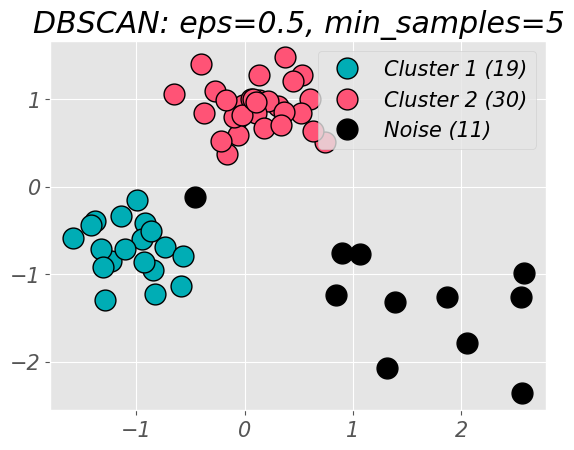

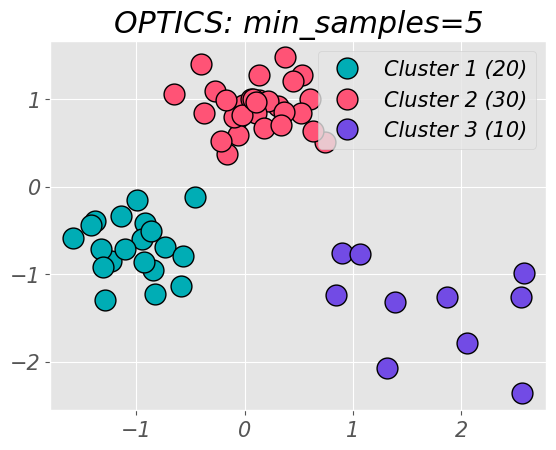

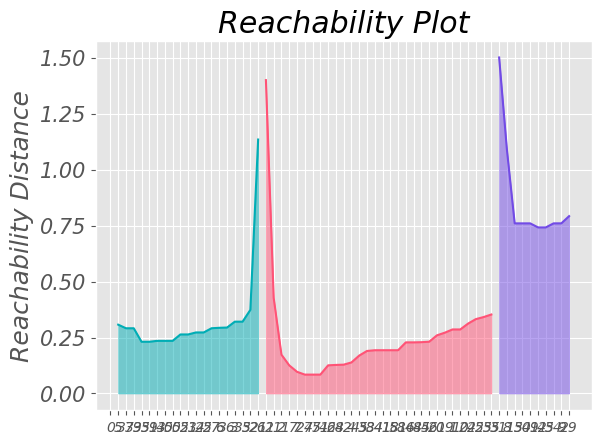

In [ ]:




plt.style.use("ggplot")
colors = ["#00ADB5", "#FF5376", "#724BE5", "#FDB62F"]
plt.rcParams.update({"font.size": 15})


def plot_clusters(algorithm, _df, _min_samples, _eps=""):
   unique_labels = set(_df.labels)
   for k, col in zip(unique_labels, colors[0:len(unique_labels)]):
       # Use black color for noise
       if k == -1:
           col = "k"
       # Use different color per cluster and add labels
       plt.plot(
           _df.loc[_df.labels == k].x,
           _df.loc[_df.labels == k].y,
           "o",
           color=col,
           markeredgecolor="k",
           markersize=15,
           label=(f"Cluster {k+1}" if k != -1 else "Noise")
           + f" ({_df.loc[_df.labels == k].shape[0]})",
       )
   # Add legend and title
   plt.legend(loc="upper right")
   plt.title(
       f"{algorithm}: "
       + (f"eps={_eps}, " if _eps != "" else _eps)
       + f"min_samples={_min_samples}"
   )
   plt.show()


def reachability_plot(_df, model):
   # Get reachability distances and cluster labels
   reachability = model.reachability_[model.ordering_]
   labels = model.labels_[model.ordering_]
   unique_labels = set(labels)
   space = np.arange(len(_df))
   # Generate reachability plot using different color per cluster
   for k, col in zip(unique_labels, colors):
       xk = space[labels == k]
       rk = reachability[labels == k]
       plt.plot(xk, rk, col)
       plt.fill_between(xk, rk, color=col, alpha=0.5)
   # Ordering in x-axis
   plt.xticks(space, _df.index[model.ordering_], fontsize=10)
   # Plot outliers
   plt.plot(space[labels == -1], reachability[labels == -1], "k.", alpha=0.3)
   # Add y-label and title
   plt.ylabel("Reachability Distance")
   plt.title("Reachability Plot")
   plt.show()


if __name__ == "__main__":
   # Generate data
   centers = [[1, 1], [-2, -4], [5, -7]]
   data = make_blobs(
       n_samples=[30, 20, 10],
       centers=centers,
       cluster_std=[0.8, 1, 1.5],
       random_state=0,
   )[0]
   data = StandardScaler().fit_transform(data)
   df = pd.DataFrame(dict(x=data[:, 0], y=data[:, 1]))

   # Define parameters
   eps = 0.5
   min_samples = 5
   metric = "euclidean"

   # Perform DBSCAN clustering and visualize results
   dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(df)
   df["labels"] = dbscan.labels_
   plot_clusters("DBSCAN", df, str(min_samples), str(eps))

   # Perform OPTICS clustering and visualize results
   optics = OPTICS(min_samples=min_samples, metric=metric).fit(df)
   df["labels"] = optics.labels_
   plot_clusters("OPTICS", df, str(min_samples))
   reachability_plot(df, optics)

# HDBSCAN

In [27]:
def stratified_sample(X, labels, n):
    if len(np.unique(labels)) < 2 or all(labels == -1):
        return None, None
    X_sample, _, y_sample, _ = train_test_split(X, labels, train_size=n, stratify=labels, random_state=42)
    return X_sample, y_sample

In [43]:
def HDBSCAN_tune(df, cont, cols):
    dfC = df[df['file'] == cont]
    X   = scale(dfC, cols)

    size = len(X)
    param_grid = {
        "min_cluster_size": [int(size * 0.005), int(size * 0.01)],
        "min_samples":      [int(size * 0.0025), int(size * 0.005), int(size * 0.01)],
        "cluster_selection_method": ["eom"]
    }

    grid = ParameterGrid(param_grid)
    best_score = -1
    best_model = None

    for params in grid:
        if params['min_cluster_size'] < params['min_samples']:
            continue
        dt1 = dt.now()
        print(f'{params}')
        model = HDBSCAN(**params, metric = 'manhattan')
        dt2 = dt.now()
        print(f'\tModel created: {dt2- dt1}')
        labels = model.fit_predict(X, )
        dt3 = dt.now()
        print(f'\tModel fitted: {dt3 - dt2}')
        if len(set(labels)) > 1 and np.sum(labels != -1) > 10:
            Xs, Ls = stratified_sample(X, labels, 100000)
            score = validity_index(Xs, Ls)
            dt4 = dt.now()
            print(f"\tDBCV: {score:.3f}, time: {dt4-dt3}")
            if score > best_score:
                best_score = score
                best_model = model
    return best_model


In [44]:
# best setting: 0.5% and None
HDBSCAN_tune(df, 'as', slopeCols)
HDBSCAN_tune(df, 'as', slopeSCols)
HDBSCAN_tune(df, 'as', slopeSTCols)

{'cluster_selection_method': 'eom', 'min_cluster_size': 2884, 'min_samples': 1442}
	Model created: 0:00:00.000121
	Model fitted: 0:02:07.583293
	DBCV: -0.115, time: 0:17:27.507480
{'cluster_selection_method': 'eom', 'min_cluster_size': 2884, 'min_samples': 2884}
	Model created: 0:00:00.000050
	Model fitted: 0:03:59.156021
	DBCV: -0.018, time: 0:17:22.804133
{'cluster_selection_method': 'eom', 'min_cluster_size': 5769, 'min_samples': 1442}
	Model created: 0:00:00.000038
	Model fitted: 0:02:09.809641
	DBCV: -0.115, time: 0:18:47.028387
{'cluster_selection_method': 'eom', 'min_cluster_size': 5769, 'min_samples': 2884}
	Model created: 0:00:00.000125
	Model fitted: 0:04:57.236786
	DBCV: -0.018, time: 0:22:58.841014
{'cluster_selection_method': 'eom', 'min_cluster_size': 5769, 'min_samples': 5769}
	Model created: 0:00:00.011305
	Model fitted: 0:10:03.040200
	DBCV: 0.436, time: 0:23:08.776199
{'cluster_selection_method': 'eom', 'min_cluster_size': 2884, 'min_samples': 1442}
	Model created: 0:

KeyboardInterrupt: 

In [ ]:
X_scaledO   = scale(df, slopeCols)
X_scaledS   = scale(df, slopeSCols)
X_scaledST  = scale(df, slopeSCols + slopeSTCols)
X_scaledSO  = scale(df, slopeCols + slopeSCols)
X_scaledSOT = scale(df, slopeCols + slopeSCols + slopeSTCols)

In [31]:
df[df['file'] == 'oc']

,index,combined_reach_id,reach_id,file,bendLen,up_reach_id,networkGraph,networkGroup,river_name,dn_connected_reach,...,bendRank,bendID,slope_left_normalized_smooth,slope_right_normalized_smooth,slope_out_normalized_smooth,slope_inn_normalized_smooth,slope_left_normalized_smoothSTD,slope_right_normalized_smoothSTD,slope_out_normalized_smoothSTD,slope_inn_normalized_smoothSTD
1236176,0,0.0,51111100441,oc,842.794213,5.111110e+10,0,0,NODATA,5.111110e+10,...,1,0_1,0.077639,0.126400,0.126669,0.077370,0.006616,0.010539,0.009516,0.005598
1236177,1,0.0,51111100441,oc,1022.982697,5.111110e+10,0,0,NODATA,5.111110e+10,...,2,0_2,0.109736,0.100415,0.103236,0.106915,0.065578,0.014404,0.018952,0.064766
1236178,2,0.0,51111100441,oc,1241.307149,5.111110e+10,0,0,NODATA,5.111110e+10,...,3,0_3,0.405596,0.147566,0.262954,0.290208,0.257665,0.082343,0.327893,0.082497
1236179,3,0.0,51111100441,oc,543.029701,5.111110e+10,0,0,NODATA,5.111110e+10,...,4,0_4,0.703856,0.251810,0.647573,0.308093,0.226068,0.064581,0.330674,0.040230
1236180,4,0.0,51111100441,oc,236.054038,5.111110e+10,0,0,NODATA,5.111110e+10,...,5,0_5,0.370298,0.157073,0.159386,0.367984,0.033415,0.009502,0.048899,0.005981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1343321,36290,9721.0,53159900655,oc,862.423522,5.315990e+10,406,1,NODATA,NaN,...,3,9721_3,0.033467,0.042516,0.037425,0.038559,0.001045,0.017965,0.000606,0.019422
1343322,36291,9721.0,53159900655,oc,3021.400841,5.315990e+10,406,1,NODATA,NaN,...,4,9721_4,0.072447,0.073711,0.067916,0.078242,0.072380,0.026164,0.028037,0.071185
1343323,33656,9722.0,56239000635,oc,5878.871788,5.623900e+10,520,2,NODATA,NaN,...,1,9722_1,0.014982,0.071331,0.061532,0.024781,0.000065,0.004449,0.028027,0.032540
1343324,33657,9722.0,56239000635,oc,4971.604249,5.623900e+10,520,2,NODATA,NaN,...,2,9722_2,0.015079,0.077965,0.019733,0.073311,0.000050,0.003429,0.021604,0.025083


In [16]:
print('O')
HDBSCAN_tune(X_scaledO)
print()
print('S')
HDBSCAN_tune(X_scaledO)
print()
print('SO')
HDBSCAN_tune(X_scaledO)

O
{'cluster_selection_method': 'eom', 'min_cluster_size': 1487, 'min_samples': None}
	Model created: 0:00:00.000041
	Model fitted: 0:06:31.710197
	DBCV: -0.021
{'cluster_selection_method': 'eom', 'min_cluster_size': 1487, 'min_samples': 38}
	Model created: 0:00:00.000044
	Model fitted: 0:02:24.492975
	DBCV: -0.389
{'cluster_selection_method': 'eom', 'min_cluster_size': 1487, 'min_samples': 121}
	Model created: 0:00:00.016339
	Model fitted: 0:02:34.956534
	DBCV: -0.314
{'cluster_selection_method': 'eom', 'min_cluster_size': 7438, 'min_samples': None}
	Model created: 0:00:00.008047
	Model fitted: 0:25:35.387686
	DBCV: -0.233
{'cluster_selection_method': 'eom', 'min_cluster_size': 7438, 'min_samples': 38}
	Model created: 0:00:00.005139
	Model fitted: 0:02:29.885014
	DBCV: -0.383
{'cluster_selection_method': 'eom', 'min_cluster_size': 7438, 'min_samples': 121}
	Model created: 0:00:00.000870
	Model fitted: 0:02:23.941852
	DBCV: -0.525
{'cluster_selection_method': 'eom', 'min_cluster_size': 

TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {SIGKILL(-9)}

# Merge bend GPKG files with clusters

In [72]:
cont = 'as'
keepCols = ['combined_reach_id','ER_out', 'ER_inn', 'ER_left', 'ER_right', 'slope_out', 'slope_inn','slope_left','slope_right', 'bendDistOut', 'geometry']
files = np.sort(glob(directory + f'results/single_values/{cont}_??_50_02_conf.gpkg'))
# select correct files
files = files[[12, 13, 14, 15]]

In [73]:
for i, f in enumerate(files):
    dfT = gpd.read_file(f)
    dfT = dfT[keepCols]
    if i == 0:
        gdf = dfT
    else:
        gdf = pd.concat([gdf, dfT], ignore_index= True)
# add bendRank
gdf['bendRank'] = gdf.groupby('combined_reach_id')['bendDistOut'].rank(ascending=False).astype(int)
gdf['bendID']   = gdf['combined_reach_id'].astype(int).astype(str) + '_' + gdf['bendRank'].astype(str)


In [ ]:
# Merge with labelled df
dfClusterC = dfCluster[dfCluster['file'] == cont]
dfNew = gdf.merge(dfClusterC, on = 'bendID', how = 'left')

dfNew.to_file(directory + f'results/cluster/{cont}_bend_cluster.gpkg', driver = 'GPKG')